## Imports

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## First look on data

In [20]:
reviews_df = pd.read_csv('../data/raw/AWS_dataset.csv', index_col = 0)

In [21]:
reviews_df.shape

(568454, 9)

In [22]:
reviews_df.head(10)

,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
Id,,,,,,,,,
1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...


In [23]:
reviews_df.describe()

,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,1.743817,2.22881,4.183199,1.296257e+09
std,7.636513,8.28974,1.310436,4.804331e+07
min,0.000000,0.00000,1.000000,9.393408e+08
25%,0.000000,0.00000,4.000000,1.271290e+09
50%,0.000000,1.00000,5.000000,1.311120e+09
75%,2.000000,2.00000,5.000000,1.332720e+09
max,866.000000,923.00000,5.000000,1.351210e+09


In [24]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 568454 entries, 1 to 568454
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   ProductId               568454 non-null  object
 1   UserId                  568454 non-null  object
 2   ProfileName             568428 non-null  object
 3   HelpfulnessNumerator    568454 non-null  int64 
 4   HelpfulnessDenominator  568454 non-null  int64 
 5   Score                   568454 non-null  int64 
 6   Time                    568454 non-null  int64 
 7   Summary                 568427 non-null  object
 8   Text                    568454 non-null  object
dtypes: int64(4), object(5)
memory usage: 43.4+ MB


In [25]:
reviews_df.duplicated().sum()

np.int64(281)

In [26]:
reviews_df.isnull().sum()

ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

### First insights

- Shape of that dataset is 568454 rows and 10 columns but of the columns we use like index column.

- We see that **Score** column has big class imbalance, most people choose rate 4-5 while less than 4 more rarely.

- Also we see that **HelpfulnessNumerator** and  **HelpfulnessDenominator** have low values at most but some values are big.

- This dataset has 4 **numerical** columns and 3 **categorical** columns.

- Dataset contains 281 duplicated rows. Also **ProfileName**  and **Summary** columns contain  26 and 27 Null values

- After first look on data I decided to delete duplicated row and rows with null values




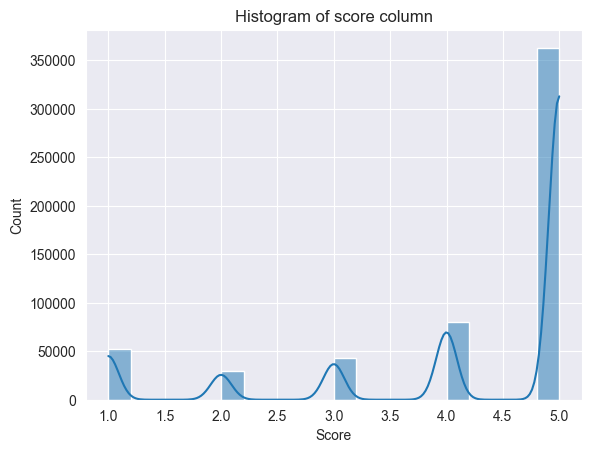

In [27]:
sns.histplot(reviews_df, x="Score", bins=20, kde=True)
plt.title("Histogram of score column")
plt.show()

In [28]:
reviews_df = reviews_df.drop_duplicates().dropna(axis = 0)

In [29]:
row_lengths = reviews_df['Text'].str.split().str.len()

average_length = row_lengths.median()

print(average_length)


56.0


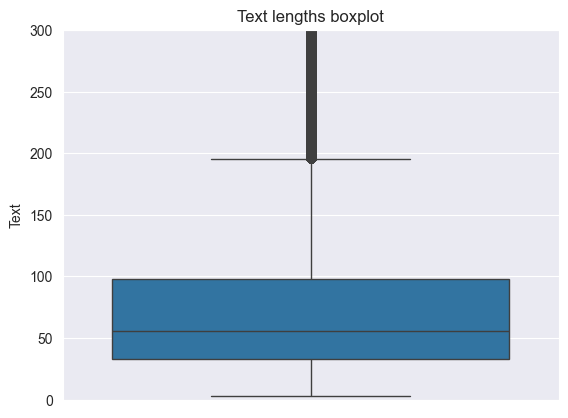

In [30]:
sns.boxplot(y=row_lengths)
plt.ylim(0, 300)
plt.title("Text lengths boxplot")
plt.show()

### Text length analysis

Median review length is 56 words, with the interquartile range roughly between 25 and 100 words —
most reviews are short to moderate in length. The boxplot (capped at 300 for readability) shows a
long right tail: some reviews exceed 1000+ words, which are extreme outliers compared to the typical review.

In [31]:
reviews_df.loc[row_lengths.idxmax(), 'Text']

'Fuzzy Wuzzy\'s Summary:<br />*** Somewhat recommended, with reservations and only lukewarm fuzzies.<br /><br />Positives:<br /><br />+ Not too expensive compared to other bottled water, although it is not cheap either.<br /><br />Negatives:<br /><br />- This bottled water product\'s labeling, product descriptions, and health claims are misleading.<br /><br />At first glance, this 1.5-liter bottle of water that I am reviewing looks like another one of the many varieties of bottled water on the market.  There are many kinds of bottled water: "spring water" produced from an underground formation where the groundwater naturally flows up to the Earth\'s surface, "artesian water" obtained from a well that taps into an underground aquifer, "mineral water" produced from a well or spring that naturally contains trace amounts of minerals that some people consider to provide health benefits, "ground/well water" produced from a well that tapes into an aquifer, "sparkling water" from a spring or w

In [32]:
reviews_df.Score.value_counts()

Score
5    362916
4     80626
1     52227
3     42612
2     29739
Name: count, dtype: int64

### Text quality & class distribution insights

Longest review confirms presence of HTML artifacts (`<br />` tags) — these need to be stripped
during text preprocessing, not just in outlier reviews but likely dataset-wide.

Score distribution is heavily imbalanced: 5-star reviews make up 64% of the dataset, while
2-star and 3-star reviews combined make up only ~12%. This will need to be addressed either
through the classification target definition (binary vs multiclass) or through model-level
techniques (class weights, resampling).

### Target definition decision

Given the class imbalance observed in the Score distribution (5-star reviews make up 64% of
the dataset), a binary sentiment classification approach was chosen over multiclass:

- **Positive**: Score 4-5
- **Negative**: Score 1-2
- **Neutral (Score 3)**: excluded from training data

Score 3 reviews are dropped rather than treated as a separate class. Neutral reviews are
inherently ambiguous (mixed sentiment is common — e.g. "good product but slow delivery"),
and including them as a third class would blur the decision boundary between positive and
negative without adding much practical value, since the goal is a clear positive/negative
sentiment signal.

This mirrors the binary classification approach used in the credit-risk-analysis project,
allowing consistent use of techniques like class weighting and threshold tuning already applied there.

In [33]:
reviews_df.to_csv('../data/processed/reviews_clean.csv', index=True)